In [7]:
import random
import torch
from data_loader import SingleEventSyntheticDataLoader, get_data_loader
import pandas as pd
import numpy as np
from SurvivalEVAL import SurvivalEvaluator
from sksurv.linear_model import CoxPHSurvivalAnalysis
from SurvivalEVAL.Evaluations.util import predict_median_survival_time
from scipy.interpolate import interp1d

from metrics import DependentEvaluator
from sota.sksurv import make_cox_model
from strategies import make_semi_synth
from utility.data import dotdict, fix_types, subsample_dataset
from utility.preprocessor import Preprocessor
from utility.survival import (convert_to_structured, kendall_tau_to_theta,
                              make_stratified_split, make_time_bins)

from sksurv.metrics import concordance_index_ipcw
from models import Weibull_log_linear, Weibull_model
from copula import Clayton_Bivariate

np.random.seed(0)
torch.manual_seed(0)
random.seed(0)

dtype = torch.float64
torch.set_default_dtype(dtype)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset_name = "seer_stomach"

# Load data
dl = get_data_loader(dataset_name).load_data()
df_full = dl.get_data().reset_index(drop=True)
num_features, cat_features = dl.get_features()

# Preprocess full dataset
preprocessor = Preprocessor(cat_feat_strat='mode', num_feat_strat='mean', scaling_strategy="minmax")
transformer = preprocessor.fit(df_full.drop(['time', 'event'], axis=1),
                                cat_feats=cat_features, num_feats=num_features,
                                one_hot=True, fill_value=-1)
X = transformer.transform(df_full.drop(['time', 'event'], axis=1)).reset_index(drop=True)
df_full = pd.concat([X, df_full[['time', 'event']]], axis=1)

# Make semi-synthetic dataset
df_synth = make_semi_synth(df_full, strategy="original")

# Subsample
if dataset_name == "metabric":
    df_subsample = subsample_dataset(df_synth.copy(), dataset_name)
elif dataset_name == "mimic_all":
    df_subsample = subsample_dataset(df_synth.copy(), dataset_name, target_size=10000)
elif dataset_name == "mimic_hospital":
    df_subsample = subsample_dataset(df_synth.copy(), dataset_name, censor_ratio=5, target_size=10000)
elif dataset_name in ["seer_brain", "seer_liver", "seer_stomach"]:
    df_subsample = subsample_dataset(df_synth.copy(), dataset_name, target_size=10000)
else:
    raise ValueError("Invalid dataset")
    
# Split data
df_train, df_valid, df_test = make_stratified_split(df_subsample, stratify_colname='both', frac_train=0.7,
                                                    frac_valid=0.1, frac_test=0.2,
                                                    random_state=0)

# Fix types
df_train, df_valid, df_test = fix_types(df_train, df_valid, df_test)

# Process data
data_train = df_train.drop(columns=["true_time", "true_censor"])
true_valid_time = df_valid.true_time.values
true_valid_event = np.ones(df_valid.shape[0])
data_valid = df_valid.drop(columns=["true_time", "true_censor"])
data_test = df_test.drop(columns=["true_time", "true_censor"])
X_train = data_train.drop(columns=["time", "event"])
X_valid = data_valid.drop(columns=["time", "event"])
X_test = data_test.drop(columns=["time", "event"])

# Format data
train_dict, valid_dict, test_dict = dict(), dict(), dict()
train_dict['X'] = torch.tensor(X_train.values, device=device, dtype=dtype)
train_dict['T'] = torch.tensor(data_train['time'].values.astype(np.int64), device=device, dtype=dtype)
train_dict['E'] = torch.tensor(data_train['event'].values.astype(np.float64), device=device, dtype=dtype)
valid_dict['X'] = torch.tensor(X_valid.values, device=device, dtype=dtype)
valid_dict['T'] = torch.tensor(data_valid['time'].values.astype(np.int64), device=device, dtype=dtype)
valid_dict['E'] = torch.tensor(data_valid['event'].values.astype(np.float32), device=device, dtype=dtype)
n_samples = train_dict['X'].shape[0]
n_features = train_dict['X'].shape[1]

# Make time bins
time_bins = make_time_bins(train_dict['T'].cpu(), event=train_dict['E'].cpu(), dtype=dtype).to(device)
time_bins = torch.cat((torch.tensor([0]).to(device), time_bins))

KeyboardInterrupt: 

In [19]:
import math
import torch
from torch.utils.data import DataLoader, TensorDataset
from trainer import loss_function
from metrics import DependentEvaluator

def get_survival_outputs(model, X, time_bins):
    """
    Build survival outputs array for evaluation.
    survival_outputs shape: [n_samples, n_time_bins, 2]
    """
    model.eval()
    with torch.no_grad():
        n_samples = X.shape[0]
        n_times = len(time_bins)
        surv_out = np.zeros((n_samples, n_times))
        for j, t in enumerate(time_bins):
            s = model.survival(t, X).cpu().numpy()
            surv_out[:, j] = s
    return surv_out

def train_copula_model(model1, model2, train_data, val_data,
                       n_epochs, batch_size=32,
                       verbose=False, copula=None,
                       theta_patience=100, val_patience=100,
                       time_bins=None,
                       true_valid_time=None, true_valid_event=None,
                       best_copula_name="clayton"):
    # Enable gradients for models
    model1.enable_grad()
    model2.enable_grad()
    if copula is not None:
        copula.enable_grad()
    
    best_val_loss = float('inf')
    best_model1_weights = None
    best_model2_weights = None
    best_copula_theta = None
    
    # Optimizer
    optimizer_params = [{"params": model1.parameters(), "lr": 1e-3},
                        {"params": model2.parameters(), "lr": 1e-3}]
    if copula is not None:
        optimizer_params.append({"params": copula.parameters(), "lr": 1e-2})
    
    optimizer = torch.optim.Adam(optimizer_params)

    # DataLoaders
    train_loader = DataLoader(
        TensorDataset(train_data['T'], train_data['X'], train_data['E']),
        batch_size=batch_size, shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(val_data['T'], val_data['X'], val_data['E']),
        batch_size=batch_size, shuffle=False
    )

    # Track stagnation
    theta_stop_itr = 0
    last_theta = None
    val_stop_itr = 0
    
    # Tracking metrics
    ci_true_list, ci_indep_list, ci_dep_list = [], [], []
    ibs_true_list, ibs_indep_list, ibs_dep_list = [], [], []
    mae_true_list, mae_indep_list, mae_dep_list = [], [], []
    
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        
        # Training loop
        for T, X, E in train_loader:
            batch_data = {'T': T, 'X': X, 'E': E}
            loss = loss_function(model1, model2, batch_data, copula)

            if torch.isnan(loss).any():
                print(f"NaN detected in training loss at epoch {epoch}. Stopping training.")
                break

            loss.backward()

            # Scale gradients
            if copula is not None:
                copula.theta.grad = copula.theta.grad * 100
                copula.theta.grad = copula.theta.grad.clamp(-1, 1)

            optimizer.step()

            # Ensure valid theta
            if copula is not None:
                if copula.theta <= 0:
                    with torch.no_grad():
                        copula.theta[:] = torch.clamp(copula.theta, 0.001, 30)

        # Validation
        with torch.no_grad():
            val_loss = 0.0
            for T, X, E in val_loader:
                batch_data = {'T': T, 'X': X, 'E': E}
                batch_val_loss = loss_function(model1, model2, batch_data, copula).item()
                val_loss += batch_val_loss
            val_loss /= len(val_loader)
            
            # --- Survival outputs from model1 ---
            if epoch % 10 == 0:
                survival_outputs = get_survival_outputs(model1, val_data['X'], time_bins)

                # True metrics
                true_eval = SurvivalEvaluator(survival_outputs, time_bins,
                                            true_valid_time, true_valid_event)
                ci_true = true_eval.concordance()[0]
                ibs_true = true_eval.integrated_brier_score(IPCW_weighted=False, num_points=10)
                mae_true = true_eval.mae(method="Uncensored")

                # Independent metrics (BG, alpha=0)
                indep_eval = DependentEvaluator(
                    survival_outputs, time_bins,
                    val_data['T'].cpu().numpy(), val_data['E'].cpu().numpy(),
                    train_data['T'].cpu().numpy(), train_data['E'].cpu().numpy(),
                    copula_name="clayton", alpha=0
                )
                ci_indep = indep_eval.concordance(method="BG")[0]
                ibs_indep = indep_eval.integrated_brier_score(method="BG", num_points=10)
                mae_indep = indep_eval.mae(method="BG")

                # Dependent metrics (BG, alpha=θ)
                dep_eval = DependentEvaluator(
                    survival_outputs, time_bins,
                    val_data['T'].cpu().numpy(), val_data['E'].cpu().numpy(),
                    train_data['T'].cpu().numpy(), train_data['E'].cpu().numpy(),
                    copula_name=best_copula_name,
                    alpha=copula.theta.item()
                )
                ci_dep = dep_eval.concordance(method="BG")[0]
                ibs_dep = dep_eval.integrated_brier_score(method="BG", num_points=10)
                mae_dep = dep_eval.mae(method="BG")

                # Save them
                ci_true_list.append(ci_true); ci_indep_list.append(ci_indep); ci_dep_list.append(ci_dep)
                ibs_true_list.append(ibs_true); ibs_indep_list.append(ibs_indep); ibs_dep_list.append(ibs_dep)
                mae_true_list.append(mae_true); mae_indep_list.append(mae_indep); mae_dep_list.append(mae_dep)
            
            if verbose and epoch % 10 == 0:
                copula_theta = copula.theta.item() if copula is not None else None
                print(f"Epoch {epoch}, Validation Loss: {val_loss:.3f} - Copula Theta: {copula_theta:.3f}")

            if val_loss < best_val_loss - 1e-6:  # tiny tolerance
                best_model1_weights = model1.state_dict()
                best_model2_weights = model2.state_dict()
                best_copula_theta = copula.theta.detach().clone() if copula is not None else None
                best_val_loss = val_loss
                val_stop_itr = 0  # reset patience if improved
            else:
                val_stop_itr += 1

        # Early stopping
        if copula is not None:
            theta_val = copula.theta.detach().cpu().item()
            min_free_theta = 1e-2
            min_epochs = 2000
            theta_abs_tol = 1e-3
            theta_rel_tol = 1e-4
            
            if abs(theta_val) > min_free_theta:
                if last_theta is None:
                    last_theta = theta_val
                else:
                    abs_change = abs(theta_val - last_theta)
                    denom = max(abs(last_theta), 1e-12)
                    rel_change = abs_change / denom
                    if abs_change < theta_abs_tol and rel_change < theta_rel_tol:
                        theta_stop_itr += 1
                    else:
                        theta_stop_itr = 0
                    last_theta = theta_val
            else:
                theta_stop_itr = 0
                last_theta = theta_val

        if epoch >= min_epochs and theta_stop_itr >= theta_patience and val_stop_itr >= val_patience:
            break

    # Restore best
    if best_model1_weights is not None:
        model1.load_state_dict(best_model1_weights)
    if best_model2_weights is not None:
        model2.load_state_dict(best_model2_weights)
    if copula is not None and best_copula_theta is not None:
        copula.theta = best_copula_theta

    return model1, model2, copula, best_val_loss, (
        ci_true_list, ci_indep_list, ci_dep_list,
        ibs_true_list, ibs_indep_list, ibs_dep_list,
        mae_true_list, mae_indep_list, mae_dep_list
    )

In [ ]:
dep_model1 = Weibull_model(n_features, dtype=dtype, device=device)
dep_model2 = Weibull_model(n_features, dtype=dtype, device=device)
copula = Clayton_Bivariate(2.0, 1e-4, dtype=dtype, device=device)

n_epochs = 5000
dep_model1, dep_model2, copula, min_val_loss, metrics = train_copula_model(
    dep_model1, dep_model2, train_dict, valid_dict,
    copula=copula, n_epochs=n_epochs,
    time_bins=time_bins, true_valid_time=true_valid_time,
    true_valid_event=true_valid_event, best_copula_name="clayton", verbose=False)

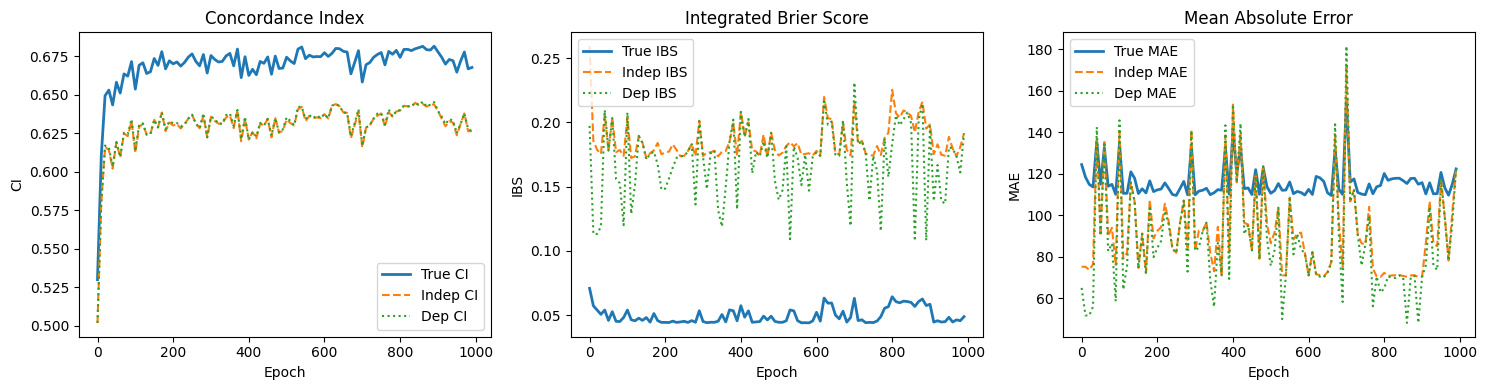

In [ ]:
import matplotlib.pyplot as plt

ci_true, ci_indep, ci_dep, ibs_true, ibs_indep, ibs_dep, mae_true, mae_indep, mae_dep = metrics
epochs = [i for i in range(0, n_epochs, 100)]

plt.figure(figsize=(15, 4))

# --- CI ---
plt.subplot(1, 3, 1)
plt.plot(epochs, ci_true, label="True CI", linewidth=2)
plt.plot(epochs, ci_indep, label="Indep CI", linestyle="--")
plt.plot(epochs, ci_dep, label="Dep CI", linestyle=":")
plt.xlabel("Epoch")
plt.ylabel("CI")
plt.title("Concordance Index")
plt.legend()

# --- IBS ---
plt.subplot(1, 3, 2)
plt.plot(epochs, ibs_true, label="True IBS", linewidth=2)
plt.plot(epochs, ibs_indep, label="Indep IBS", linestyle="--")
plt.plot(epochs, ibs_dep, label="Dep IBS", linestyle=":")
plt.xlabel("Epoch")
plt.ylabel("IBS")
plt.title("Integrated Brier Score")
plt.legend()

# --- MAE ---
plt.subplot(1, 3, 3)
plt.plot(epochs, mae_true, label="True MAE", linewidth=2)
plt.plot(epochs, mae_indep, label="Indep MAE", linestyle="--")
plt.plot(epochs, mae_dep, label="Dep MAE", linestyle=":")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Mean Absolute Error")
plt.legend()

plt.tight_layout()
plt.show()